## Dados coletados do Kaggle
https://www.kaggle.com/datasets/blastchar/telco-customer-churn

Iremos utilizar esta base de dados para aprendizagem e aperfeiçoamento na área de dados.

Análises que iremos verificar:
- Taxa de churn
- Churn por tipo de contrato
- Churn por faixa de preço
- Churn por tempo de cliente
- Análises multivariadas (combinações de fatores)
- Engajamento (nº de serviços) vs churn

### Dicionário de dados

| Coluna | Descrição |
|---|---|
| **gender** | Masculino ou feminino |
| **SeniorCitizen** | Idoso (1) ou não (0) |
| **tenure** | Meses de permanência com a empresa |
| **Partner** | Possui parceiro(a) |
| **Dependents** | Possui dependentes |
| **PhoneService** | Possui serviço de telefone |
| **MultipleLines** | Possui múltiplas linhas |
| **InternetService** | Tipo de internet (DSL, Fibra, Nenhum) |
| **OnlineSecurity** | Segurança online |
| **OnlineBackup** | Backup online |
| **DeviceProtection** | Proteção de dispositivos |
| **TechSupport** | Suporte técnico |
| **StreamingTV** | Streaming de TV |
| **StreamingMovies** | Streaming de filmes |
| **Contract** | Tipo de contrato (Mensal, 1 ano, 2 anos) |
| **PaperlessBilling** | Faturamento digital |
| **PaymentMethod** | Método de pagamento |
| **MonthlyCharges** | Valor mensal cobrado |
| **TotalCharges** | Valor total cobrado |
| **Churn** | Cancelou o serviço (1=Sim, 0=Não) |

## 1. Carregamento e limpeza dos dados

In [73]:
import v1_dados
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from importlib import reload
from v1_dados import dados_arquivos
from v3_limpeza_dados import dados_tratados
from config import PROCESSED_DATA_PATH

In [74]:
reload(v1_dados)

df = dados_arquivos()
df = dados_tratados(df)

print(f"Shape: {df.shape}")
df.head()

Shape: (7032, 24)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,faixa_preco,tenure_group,n_servicos
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,Muito Baixo,0-12 meses,1
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,One year,No,Mailed check,56.95,1889.50,0,Baixo,24-48 meses,2
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,Baixo,0-12 meses,2
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,Baixo,24-48 meses,3
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,Médio,0-12 meses,0


In [75]:
# Separando colunas numéricas e categóricas para análise
# Churn agora é numérico (0/1), por isso excluímos manualmente das categóricas
colunas_numericas = df.select_dtypes(include='number').columns
colunas_categoricas = df.select_dtypes(exclude='number').columns

print('Númericas:', list(colunas_numericas))
print('Categóricas:', list(colunas_categoricas))

Númericas: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn', 'n_servicos']
Categóricas: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'faixa_preco', 'tenure_group']


## 2. Análise das variáveis numéricas

### Histogramas
- Um histograma é uma representação gráfica da distribuição de frequências de uma variável. Permite identificar assimetrias e outliers.

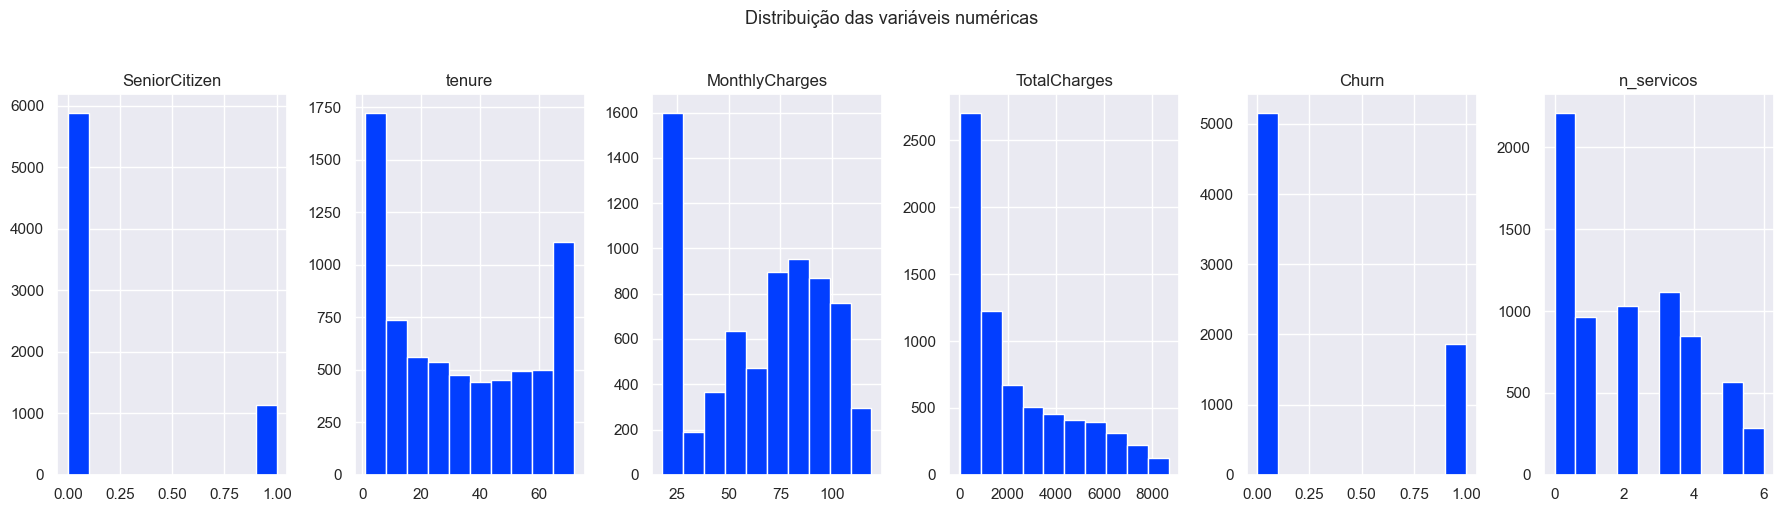

In [76]:
df[colunas_numericas].hist(layout=(1, len(colunas_numericas)), figsize=(18, 5));
plt.suptitle('Distribuição das variáveis numéricas', y=1.02, fontsize=13)
plt.tight_layout()

In [77]:
# Distribuição de TotalCharges por faixas
df['TotalCharges'].value_counts(bins=10).sort_index()

(10.133000000000001, 885.4]    2709
(885.4, 1752.0]                1228
(1752.0, 2618.6]                671
(2618.6, 3485.2]                508
(3485.2, 4351.8]                454
(4351.8, 5218.4]                412
(5218.4, 6085.0]                395
(6085.0, 6951.6]                310
(6951.6, 7818.2]                223
(7818.2, 8684.8]                122
Name: count, dtype: int64

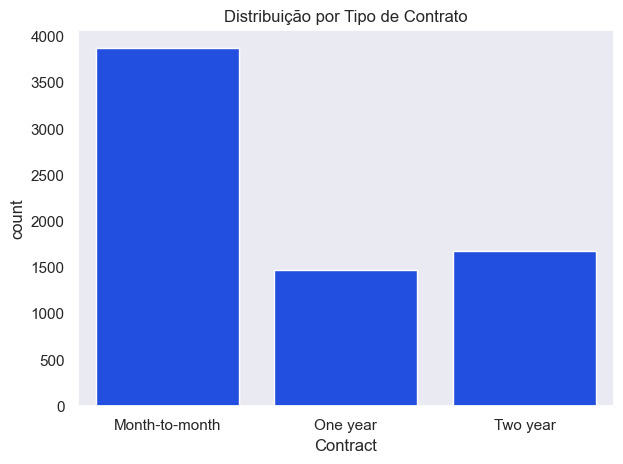

In [78]:
# Tipo de contrato mais comum
sns.countplot(data=df, x='Contract')
plt.title('Distribuição por Tipo de Contrato')
plt.tight_layout()

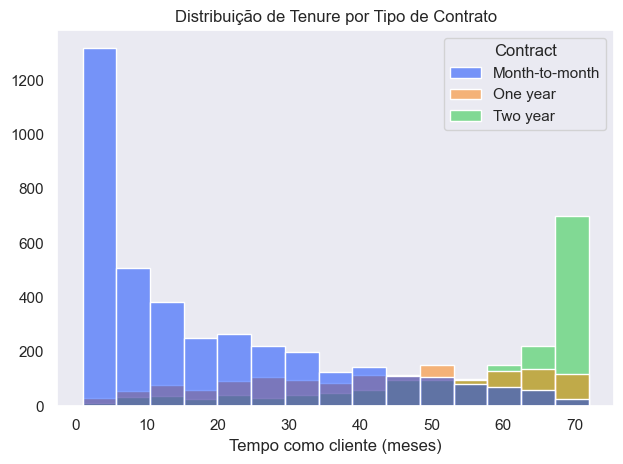

In [79]:
# Distribuição de tenure por tipo de contrato
# Analisando o gráfico, a modalidade mês a mês concentra clientes com menor tenure,
# o que está diretamente ligado ao maior churn nesse grupo.
sns.set_theme(style='dark', palette='bright', context='notebook')
sns.histplot(x='tenure', data=df, hue='Contract')
plt.title('Distribuição de Tenure por Tipo de Contrato')
plt.xlabel('Tempo como cliente (meses)')
plt.ylabel('')
plt.tight_layout()


## 3. Método de pagamento vs Churn

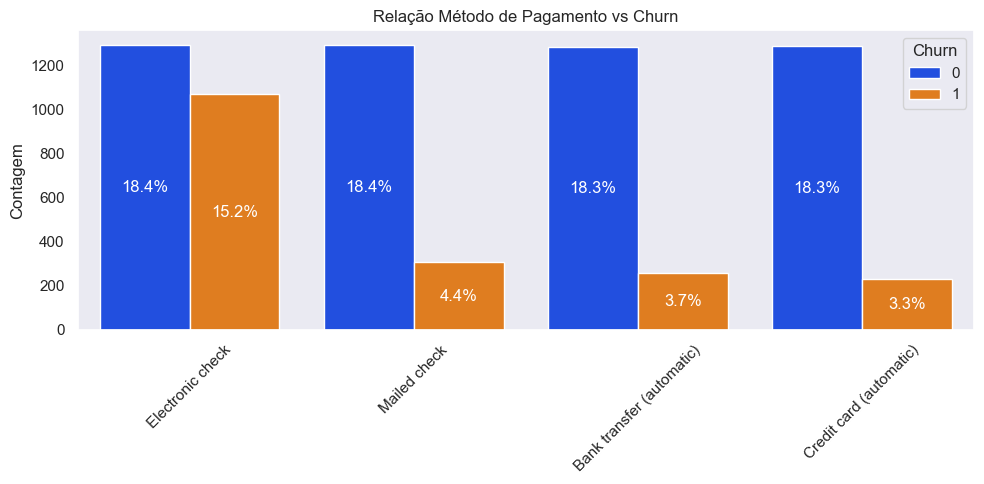

In [80]:
# Fica claro a discrepância entre pagamento automático (cartão de crédito)
# e métodos manuais como boleto (Electronic check).
plt.figure(figsize=(10,5))
ax = sns.countplot(data=df, x='PaymentMethod', hue='Churn')

total = len(df)
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        percentage = f'{100 * height/total:.1f}%'
        ax.annotate(percentage, (p.get_x() + p.get_width() / 2, height / 2), 
                    ha='center', va='center', color='white')
        

plt.title('Relação Método de Pagamento vs Churn')
plt.xlabel('')
plt.ylabel('Contagem')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Variáveis numéricas vs Churn

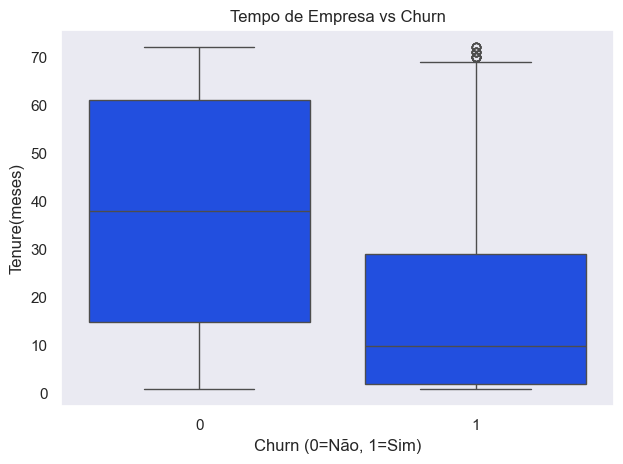

In [81]:
# Pessoas que cancelam têm menor tempo de empresa
sns.boxplot(data=df, x='Churn', y='tenure')
plt.title('Tempo de Empresa vs Churn')
plt.xlabel('Churn (0=Não, 1=Sim)')
plt.ylabel('Tenure(meses)')
plt.tight_layout()

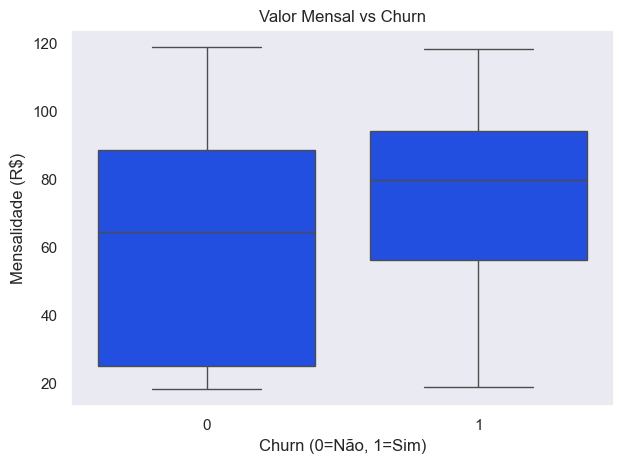

In [82]:
# Pagamentos altos afetam o cancelamento
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title('Valor Mensal vs Churn')
plt.xlabel('Churn (0=Não, 1=Sim)')
plt.ylabel('Mensalidade (R$)')
plt.tight_layout()

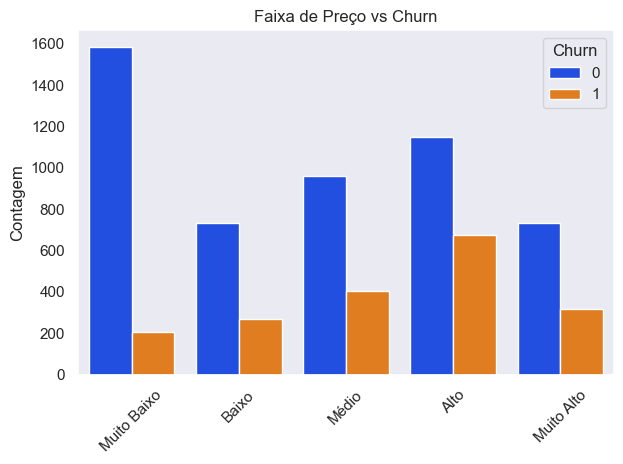

In [83]:
# Faixa de preço vs churn
# Planos com maior valor tendem a ter mais cancelamentos
sns.countplot(data=df, x='faixa_preco', hue='Churn')
plt.title('Faixa de Preço vs Churn')
plt.xlabel('')
plt.ylabel('Contagem')
plt.xticks(rotation=45)
plt.tight_layout()

## 5. Heatmap de correlação

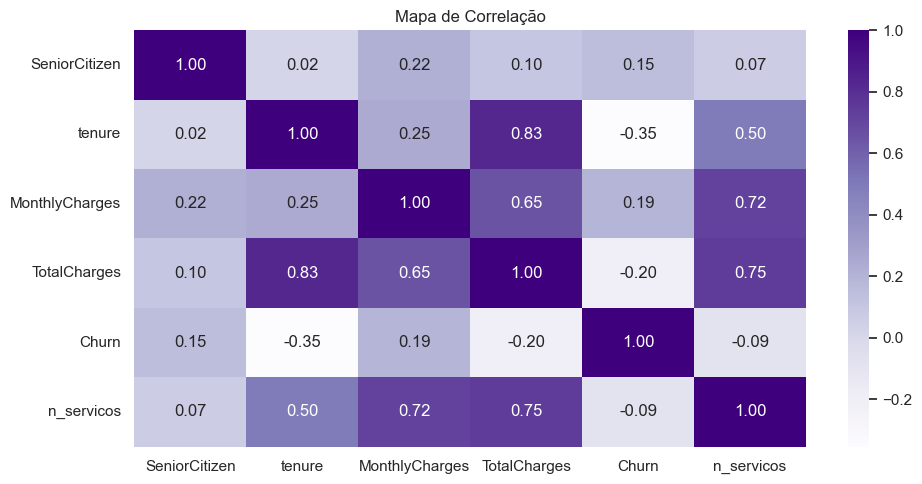

In [84]:
# Correlação entre tenure e TotalCharges é esperada (quanto mais tempo, maior o total pago).
# O interessante é verificar a correlação de Churn com as demais variáveis numéricas.
plt.figure(figsize=(10, 5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Purples', fmt='.2f')
plt.title('Mapa de Correlação')
plt.tight_layout()

## 6. Questionamentos de negócio

### Q1. Qual é a taxa geral de churn?

In [85]:
taxa = df['Churn'].value_counts(normalize=True).mul(100).round(2)
print(f'Não cancelou: {taxa[0]}%')
print(f'Cancelou: {taxa[1]}%')

Não cancelou: 73.42%
Cancelou: 26.58%


### Q2. Clientes novos cancelam mais?

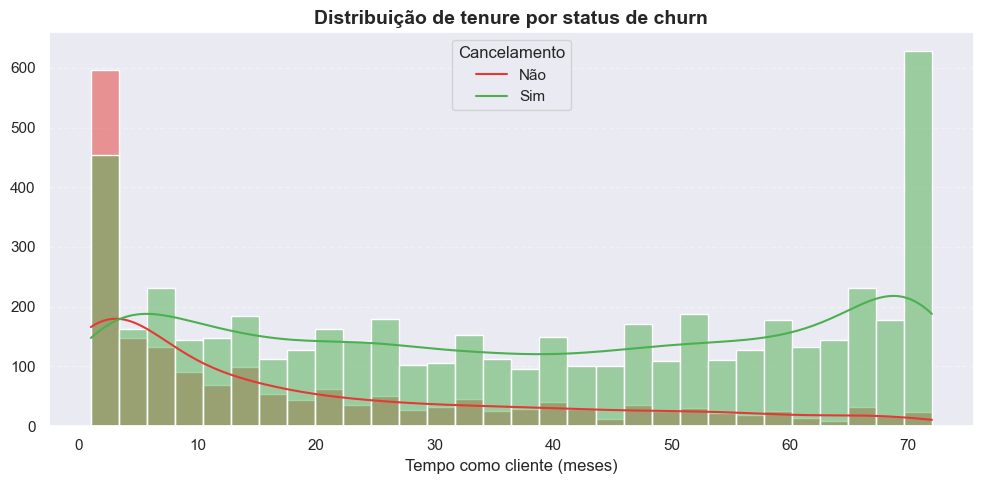

In [86]:
# R: Sim. Clientes com menor tempo de contrato apresentam maior taxa de churn,
# indicando necessidade de ações de retenção nos primeiros meses.
plt.figure(figsize=(10,5))

palette = {0: '#4CAF50', 1: '#E53935'}

sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True, palette=palette, alpha=0.5)


plt.title('Distribuição de tenure por status de churn', fontsize=14, weight='bold')
plt.xlabel('Tempo como cliente (meses)')
plt.ylabel('')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.legend(title='Cancelamento', labels=['Não', 'Sim'])
plt.tight_layout()
plt.show()

### Q3. O tipo de contrato influencia no churn?

<Figure size 1000x500 with 0 Axes>

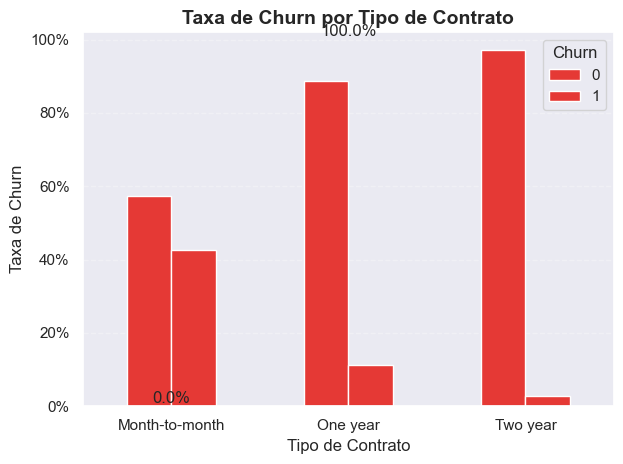

In [87]:
# R: Sim. Contratos mensais têm churn muito maior do que contratos anuais ou bianuais.
churn_rate = (df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack())

plt.figure(figsize=(10,5))
churn_rate.plot(kind='bar', color='#E53935')

plt.title('Taxa de Churn por Tipo de Contrato', fontsize=14, weight='bold')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Taxa de Churn')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

for i, v in enumerate(churn_rate):
    plt.text(i, v + 0.01, f'{v:.1%}', ha='center')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Q4. Clientes que pagam mais cancelam mais?

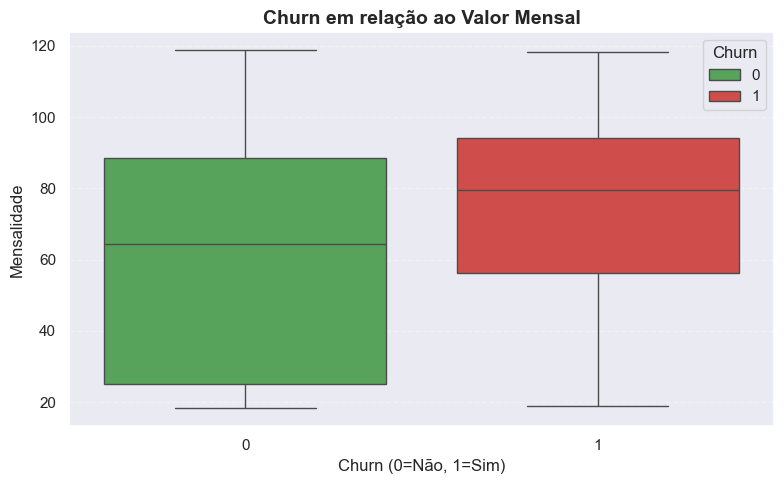

In [88]:
# R: Sim. Clientes com maior valor mensal tendem a ter maior dispersão
# e leve tendência ao churn — possível sensibilidade a preço.
plt.figure(figsize=(8,5))

palette = {0: '#4CAF50', 1: '#E53935'}

sns.boxplot(data=df,x='Churn', y='MonthlyCharges', hue='Churn',palette=palette)

plt.title('Churn em relação ao Valor Mensal', fontsize=14, weight='bold')
plt.xlabel('Churn (0=Não, 1=Sim)')
plt.ylabel('Mensalidade')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Q5. O tempo de empresa reduz o churn?

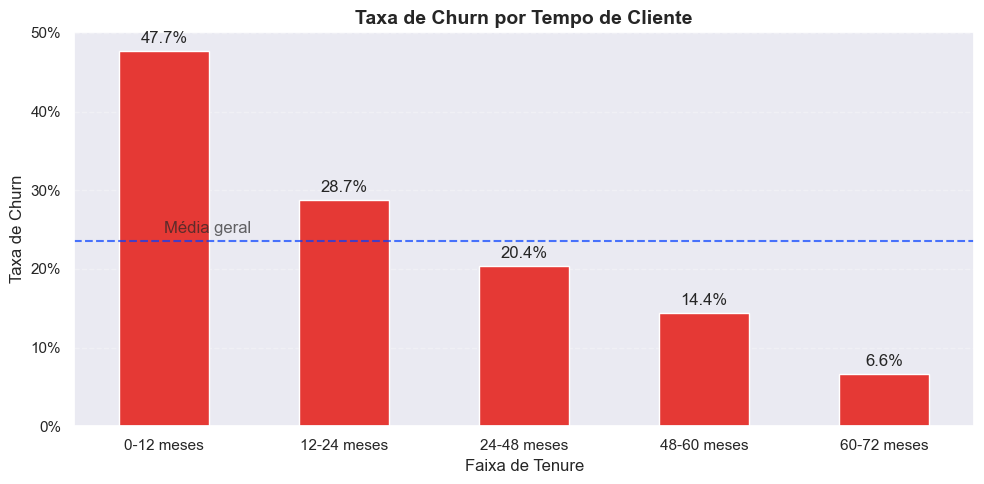

In [89]:
# R: Sim. Clientes com mais tempo de empresa têm taxa de churn progressivamente menor.
churn_rate = df.groupby('tenure_group', observed=True)['Churn'].mean()

plt.figure(figsize=(10,5))
churn_rate.plot(kind='bar', color='#E53935')

plt.title('Taxa de Churn por Tempo de Cliente', fontsize=14, weight='bold')
plt.xlabel('Faixa de Tenure')
plt.ylabel('Taxa de Churn')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

for i, v in enumerate(churn_rate):
    plt.text(i, v + 0.01, f'{v:.1%}', ha='center')


plt.axhline(y=churn_rate.mean(), linestyle='--', alpha=0.7)
plt.text(0, churn_rate.mean() + 0.01, 'Média geral', alpha=0.7)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Q6. O tipo de internet influencia o churn?

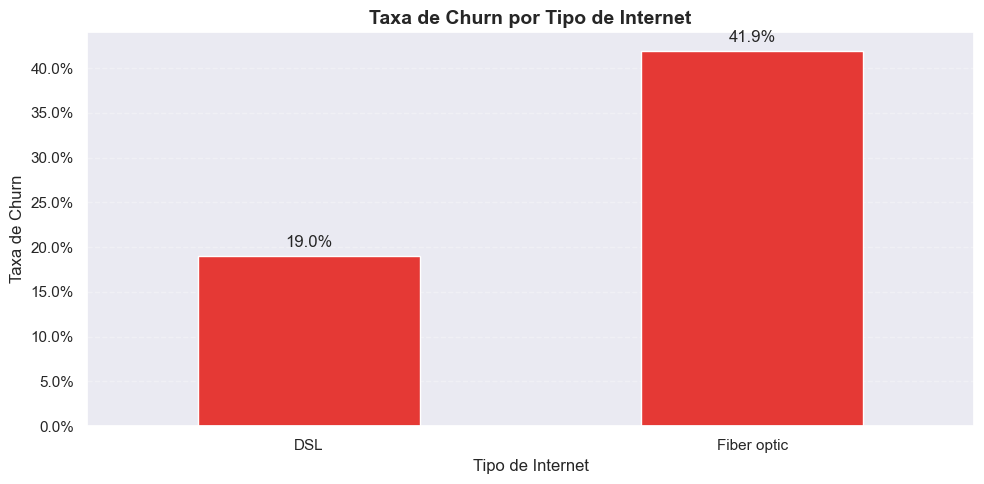

In [90]:
# R: Sim. Fibra óptica apresenta churn significativamente maior do que DSL.
# Pode indicar problema de qualidade, expectativa ou concorrência.
df_internet = df[df['InternetService'] != 'No']
churn_rate = df_internet.groupby('InternetService')['Churn'].mean()

plt.figure(figsize=(10,5))
churn_rate.plot(kind='bar', color='#E53935')

plt.title('Taxa de Churn por Tipo de Internet', fontsize=14, weight='bold')
plt.xlabel('Tipo de Internet')
plt.ylabel('Taxa de Churn')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

for i, v in enumerate(churn_rate):
    plt.text(i, v + 0.01, f'{v:.1%}', ha='center')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Q7. O método de pagamento influencia o churn?

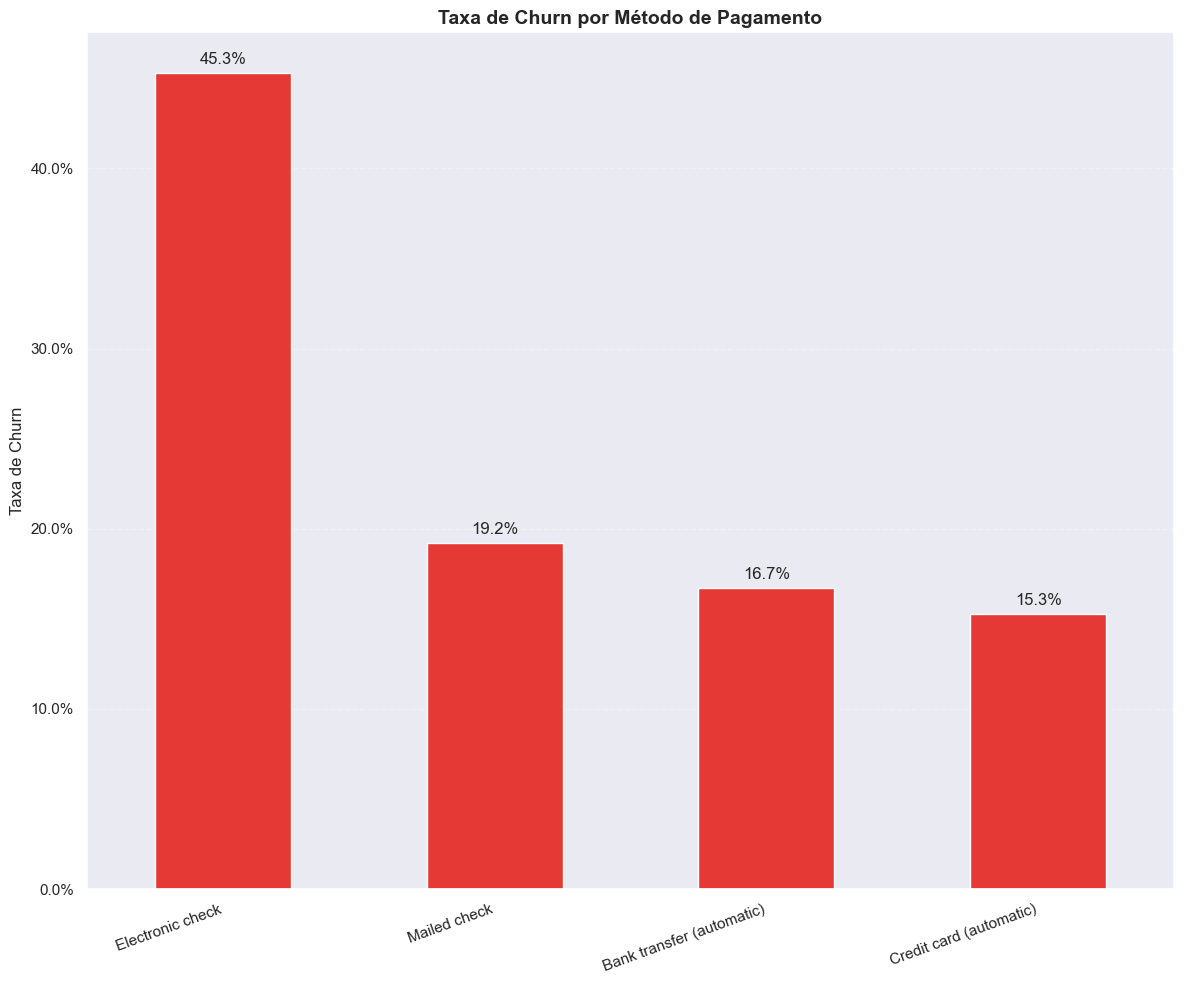

In [91]:
# R: Sim. Pagamento automático (cartão/transferência) tem menor churn.
# Cheque eletrônico (Electronic check) tem o maior churn — é o método mais manual.
churn_rate = df.groupby('PaymentMethod')['Churn'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 10))
churn_rate.plot(kind='bar', color='#E53935')

plt.title('Taxa de Churn por Método de Pagamento', fontsize=14, weight='bold')
plt.xlabel('')
plt.ylabel('Taxa de Churn')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

for i, v in enumerate(churn_rate):
    plt.text(i, v + 0.005, f'{v:.1%}', ha='center')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()


### Q8. Clientes com suporte técnico cancelam menos?

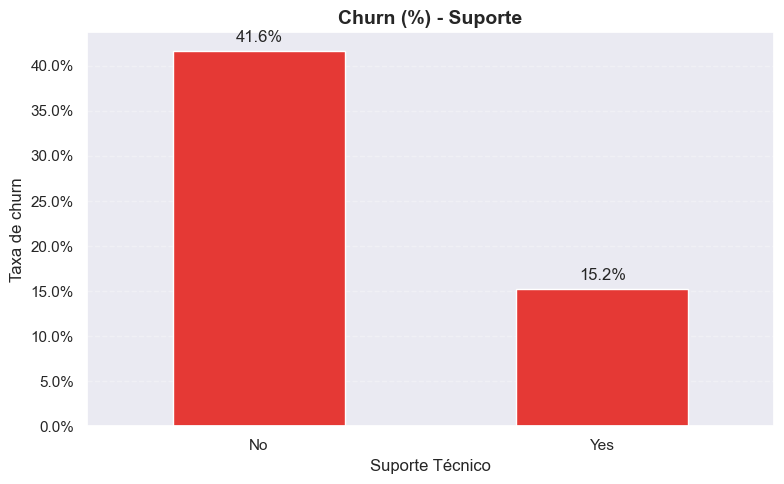

In [92]:
# R: Sim. Não ter suporte técnico quase dobra a taxa de churn.
df_tech = df[df['TechSupport'] != 'No internet service']
churn_rate = df_tech.groupby('TechSupport')['Churn'].mean()

plt.figure(figsize=(8, 5))
churn_rate.plot(kind='bar', color='#E53935')

plt.title('Churn (%) - Suporte', fontsize=14, weight='bold')
plt.xlabel('Suporte Técnico')
plt.ylabel('Taxa de churn')

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

for i, v in enumerate(churn_rate):
    plt.text(i, v + 0.01, f'{v:.1%}', ha='center')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Q9. Clientes com parceiros ou família cancelam menos?

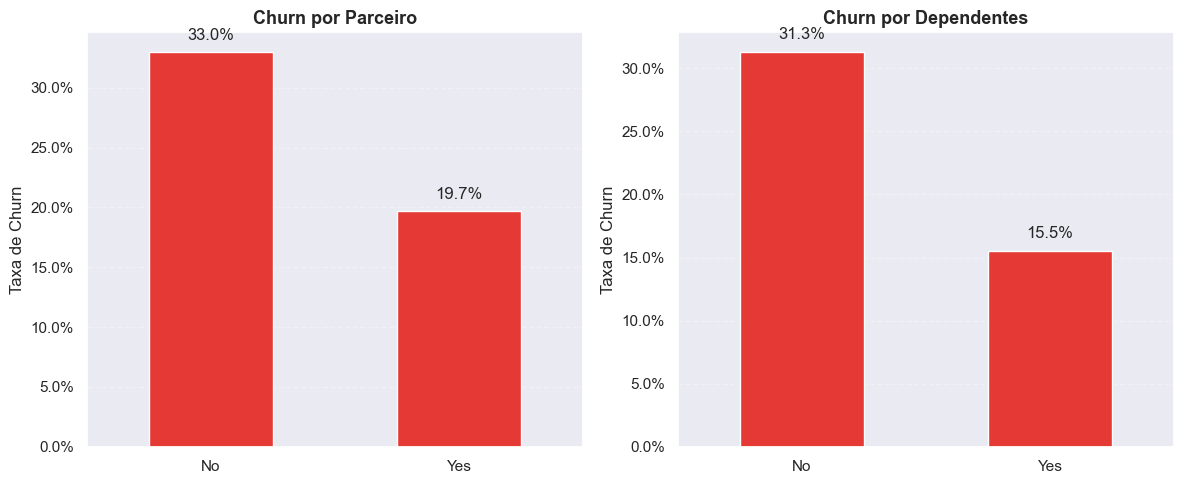

In [94]:
# R: Parceiros e dependentes reduzem levemente o churn,
# provavelmente por maior estabilidade financeira e de vida.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, titulo in zip(axes, ['Partner', 'Dependents'], ['Parceiro', 'Dependentes']):
    churn_rate = df.groupby(col)['Churn'].mean()
    churn_rate.plot(kind='bar', color='#E53935', ax=ax)
    
    ax.set_title(f'Churn por {titulo}', fontsize=13, weight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Taxa de Churn')

    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.tick_params(axis='x', rotation=0)

    for i, v in enumerate(churn_rate):
        ax.text(i, v + 0.01, f'{v:.1%}', ha='center')

plt.tight_layout()
plt.show()


### Q10. Existe relação entre valor total pago e churn?

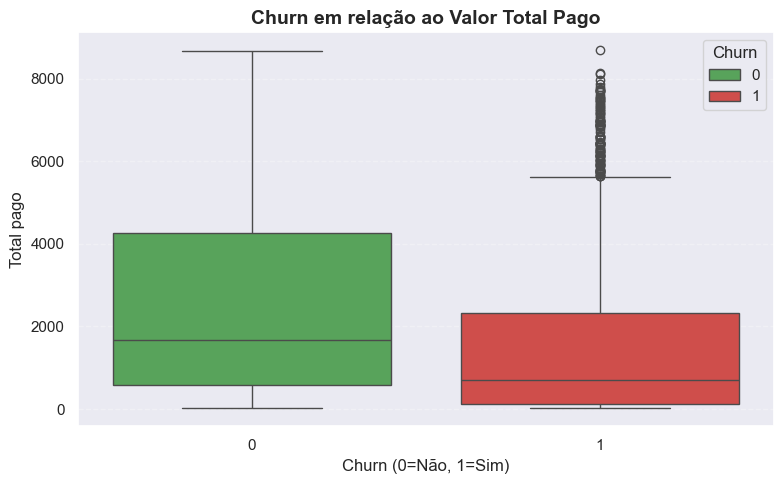

In [95]:
# R: Clientes que cancelam têm menor TotalCharges — reflexo direto de menor tenure.
# Clientes que ficam por mais tempo naturalmente acumulam maior valor total.
palette = {0: '#4CAF50', 1: '#E53935'}

plt.figure(figsize=(8,5))
sns.boxplot(data=df,x='Churn', y='TotalCharges', hue='Churn', palette=palette)

plt.title('Churn em relação ao Valor Total Pago', fontsize=14, weight='bold')
plt.xlabel('Churn (0=Não, 1=Sim)')
plt.ylabel('Total pago')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


## 7. Análises multivariadas

Combinando fatores para identificar perfis de alto risco.

### Clientes novos + contrato mensal: o perfil de maior risco

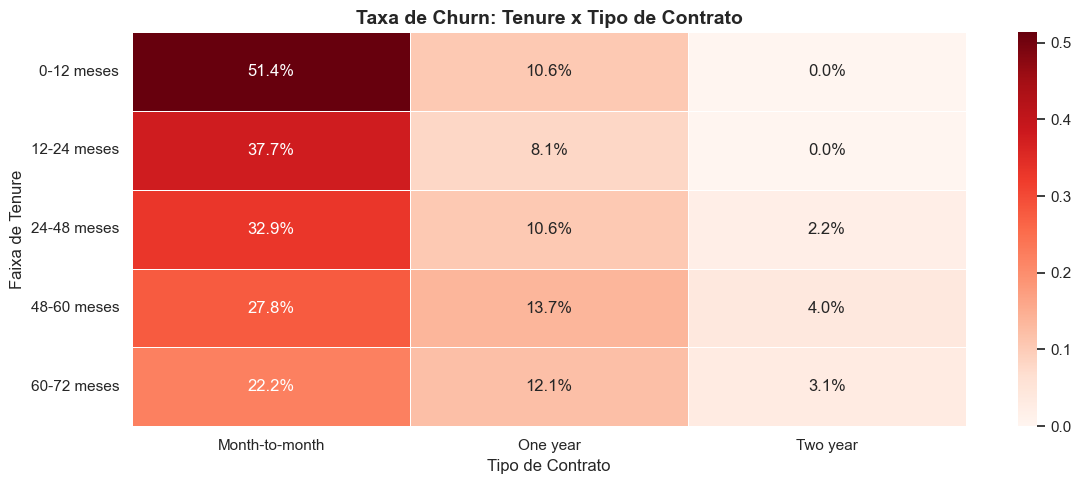

In [96]:
# Combinando tenure_group e Contract para ver onde o risco é mais alto

pivot = df.groupby(['tenure_group', 'Contract'], observed=True)['Churn'].mean().unstack()

plt.figure(figsize=(12, 5))
sns.heatmap(pivot, annot=True, fmt='.1%', cmap='Reds', linewidths=0.5)

plt.title('Taxa de Churn: Tenure x Tipo de Contrato', fontsize=14, weight='bold')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Faixa de Tenure')
plt.tight_layout()
plt.show()

### Fibra óptica + sem suporte técnico: combinação crítica

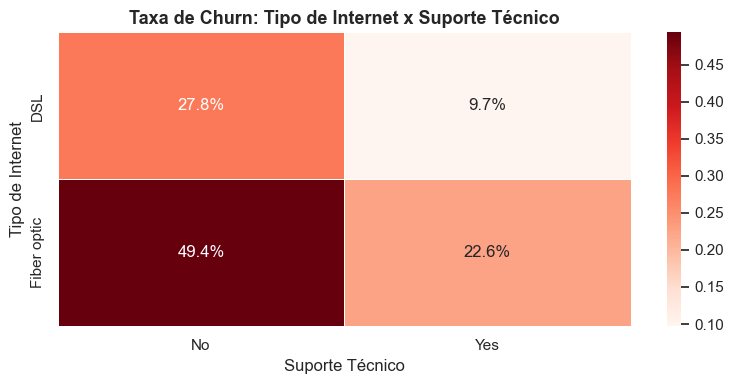

In [97]:
# Filtrando apenas quem tem internet (não faz sentido avaliar suporte sem internet)

df_net = df[df['InternetService'] != 'No']
df_net = df_net[df_net['TechSupport'] != 'No internet service']

pivot2 = df_net.groupby(['InternetService', 'TechSupport'])['Churn'].mean().unstack()

plt.figure(figsize=(8, 4))
sns.heatmap(pivot2, annot=True, fmt='.1%', cmap='Reds', linewidths=0.5)

plt.title('Taxa de Churn: Tipo de Internet x Suporte Técnico', fontsize=13, weight='bold')
plt.xlabel('Suporte Técnico')
plt.ylabel('Tipo de Internet')
plt.tight_layout()
plt.show()

### Contrato mensal + método manual de pagamento

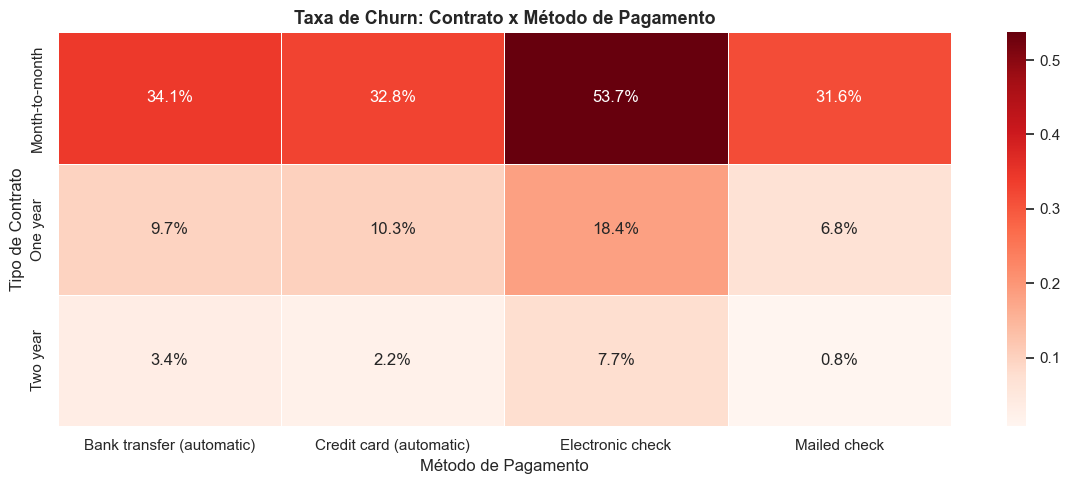

In [98]:
pivot3 = df.groupby(['Contract', 'PaymentMethod'])['Churn'].mean().unstack()

plt.figure(figsize=(12 , 5))
sns.heatmap(pivot3, annot=True, fmt='.1%', cmap='Reds', linewidths=0.5)

plt.title('Taxa de Churn: Contrato x Método de Pagamento', fontsize=13, weight='bold')
plt.xlabel('Método de Pagamento')
plt.ylabel('Tipo de Contrato')
plt.tight_layout()
plt.show()

## 8. Engajamento: nº de serviços vs churn

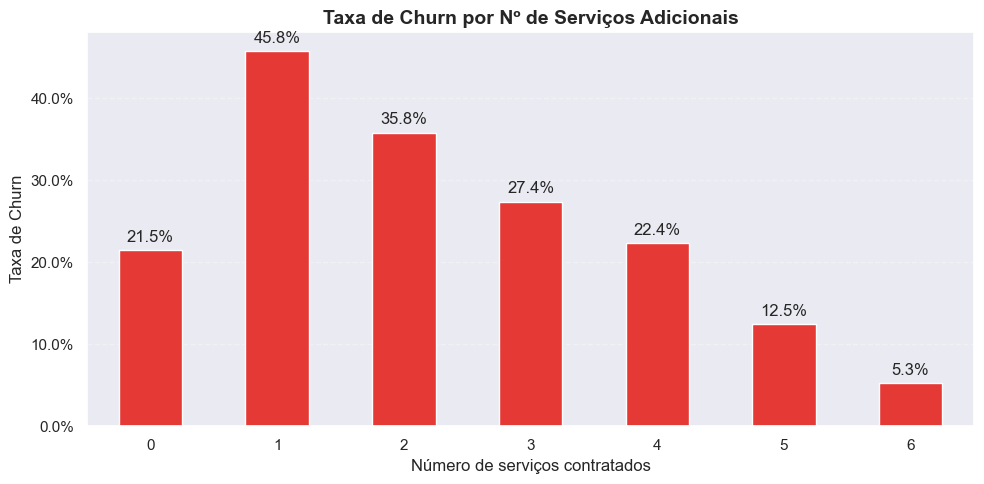

In [99]:
# R: Quanto mais serviços adicionais, menor a taxa de churn.
# Clientes com 0 serviços têm risco muito maior de cancelar.

churn_por_servicos = df.groupby('n_servicos')['Churn'].mean()

plt.figure(figsize=(10, 5))
churn_por_servicos.plot(kind='bar', color='#E53935')

plt.title('Taxa de Churn por Nº de Serviços Adicionais', fontsize=14, weight='bold')
plt.xlabel('Número de serviços contratados')
plt.ylabel('Taxa de Churn')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

for i, v in enumerate(churn_por_servicos):
    plt.text(i, v + 0.01, f'{v:.1%}', ha='center')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

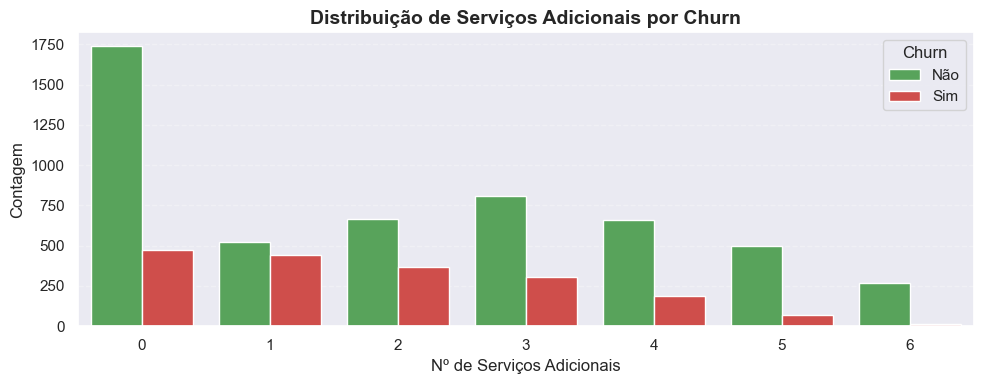

In [100]:
# Distribuição dos clientes por quantidade de serviços
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x='n_servicos', hue='Churn',
              palette={0: '#4CAF50', 1: '#E53935'})

plt.title('Distribuição de Serviços Adicionais por Churn', fontsize=14, weight='bold')
plt.xlabel('Nº de Serviços Adicionais')
plt.ylabel('Contagem')
plt.legend(title='Churn', labels=['Não', 'Sim'])
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Exportação dos dados finais para Power BI

In [101]:
import os

# Garante que a pasta de saída existe
os.makedirs('processed', exist_ok=True)

# Exporta o dataset completo e enriquecido (com todas as colunas derivadas)
df.to_csv(PROCESSED_DATA_PATH, index=False)

print(f"✅ Dados exportados para: {PROCESSED_DATA_PATH}")
print(f"   Shape: {df.shape}")
print(f"   Colunas: {list(df.columns)}")

✅ Dados exportados para: processed/dados_finais.csv
   Shape: (7032, 24)
   Colunas: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'faixa_preco', 'tenure_group', 'n_servicos']
